# 风速降尺度算法验证

本 Notebook 验证迁移版 `RoughnessCorrection`，覆盖两条路径：

1. **方案一：投影对齐 / 维名重命名**——读取预处理后的 `cli_input/`（投影维已重命名为 `lat/lon`，数值仍为米制），与 KGO、原 IMPROVER 结果做数值对照。
2. **方案二：真经纬网格 / 重网格**——读取预处理后的 `cli_input/latlon/`，迁移版在真经纬坐标上运行（`ppres` 由度间距推断为米）；与同目录下重网格后的 KGO / 原算法结果对照。

**预处理不在本 Notebook 中执行。** 请先在仓库根目录运行：

```bash
python 00temp/orographic_wind_downscaling/cli/preprocess_test_data.py
```

说明：原 Iris 插件要求投影水平坐标，不能在纯经纬网格上重跑原版；方案二对照采用「投影结果再重网格」方式。方案二差异通常大于方案一（「输入先重网格再算」与「结果后重网格」不等价）。


## 1. 环境准备


In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

plt.rcParams["font.sans-serif"] = ["SimHei", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

PACKAGE_ROOT = Path.cwd().resolve().parents[0]
PROJECT_ROOT = PACKAGE_ROOT.parent
DATA_DIR = (PACKAGE_ROOT / "test_data/wind_calculations_data").resolve()
CLI_INPUT_DIR = DATA_DIR / "cli_input"
CLI_INPUT_LATLON_DIR = CLI_INPUT_DIR / "latlon"
CLI_OUTPUT_DIR = DATA_DIR / "cli_output"
CLI_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
MODEL_RESOLUTION = 1500.0
RMDI = -32767.0

CLI_INPUT_FILES = [
    "input.nc",
    "a_over_s.nc",
    "sigma.nc",
    "highres_orog.nc",
    "standard_orog.nc",
    "veg.nc",
]
LATLON_REF_FILES = ["kgo.nc", "original_algorithm_result.nc"]

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from importlib import import_module; _cli = import_module('cli.00space_downscale.orographic_wind_downscaling.dsc_wind_downscaling_main'); cli_process = _cli.process
from importlib import import_module; _src = import_module('NIMM.00space_downscale.orographic_wind_downscaling.wind_downscaling'); RoughnessCorrection = _src.RoughnessCorrection


def _require_files(directory: Path, filenames: list[str], label: str) -> None:
    missing = [name for name in filenames if not (directory / name).exists()]
    if missing:
        raise FileNotFoundError(
            f"缺少{label}: {', '.join(missing)}。"
            f"请先运行: python 00temp/orographic_wind_downscaling/cli/preprocess_test_data.py"
            f"（期望目录 {directory}）"
        )


def compare_stats(current, reference, tag: str) -> dict[str, float]:
    """打印并返回两场差异统计（mean_abs / max_abs / rmse）。"""

    def _clean(values):
        arr = np.asarray(values, dtype=np.float32).copy()
        arr = np.nan_to_num(arr, nan=0.0, posinf=0.0, neginf=0.0)
        arr[arr == RMDI] = 0.0
        return arr

    c = _clean(np.squeeze(current.values if isinstance(current, xr.DataArray) else current))
    r = _clean(np.squeeze(reference.values if isinstance(reference, xr.DataArray) else reference))
    if c.shape != r.shape:
        raise ValueError(f"场形状不一致: current={c.shape}, reference={r.shape}, tag={tag}")
    diff = c.astype(np.float64) - r.astype(np.float64)
    stats = {
        "mean_abs": float(np.mean(np.abs(diff))),
        "max_abs": float(np.max(np.abs(diff))),
        "rmse": float(np.sqrt(np.mean(diff**2))),
    }
    print(
        f"[{tag}] mean_abs={stats['mean_abs']:.8f}, "
        f"max_abs={stats['max_abs']:.8f}, rmse={stats['rmse']:.8f}"
    )
    return stats


def to_display_2d(da: xr.DataArray) -> np.ndarray:
    """将多维 meb 场 squeeze 为二维 lat/lon，用于绘图。"""
    arr = np.squeeze(np.asarray(da.values, dtype=np.float64))
    if arr.ndim != 2:
        raise ValueError(f"期望二维空间场，当前 shape={arr.shape}")
    return arr


def to_spatial_values(data) -> np.ndarray:
    arr = np.asarray(data.values if isinstance(data, xr.DataArray) else data, dtype=np.float32)
    arr = np.nan_to_num(arr, nan=0.0, posinf=0.0, neginf=0.0)
    arr[arr == RMDI] = 0.0
    return np.squeeze(arr)


def _to_plot_ready(arr):
    data = to_spatial_values(arr)
    if data.ndim == 3:
        mid = data.shape[0] // 2
        return data[mid], f"level[{mid}]"
    return data, "surface"


_require_files(CLI_INPUT_DIR, CLI_INPUT_FILES, "方案一预处理输入")
_require_files(CLI_INPUT_LATLON_DIR, CLI_INPUT_FILES + LATLON_REF_FILES, "方案二预处理输入/对照场")

print(f"包目录: {PACKAGE_ROOT}")
print(f"数据目录: {DATA_DIR}")
print(f"CLI_INPUT_DIR: {CLI_INPUT_DIR}")
print(f"CLI_INPUT_LATLON_DIR: {CLI_INPUT_LATLON_DIR}")
print(f"模式分辨率: {MODEL_RESOLUTION} m")



d:\workspace\improver\venv\Lib\site-packages\meteva_base\basicdata\const.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


包目录: D:\workspace\improver\orographic_wind_downscaling
数据目录: D:\workspace\improver\orographic_wind_downscaling\test_data\wind_calculations_data
CLI_INPUT_DIR: D:\workspace\improver\orographic_wind_downscaling\test_data\wind_calculations_data\cli_input
CLI_INPUT_LATLON_DIR: D:\workspace\improver\orographic_wind_downscaling\test_data\wind_calculations_data\cli_input\latlon
模式分辨率: 1500.0 m


## 2. 方案一：投影对齐输入（维名重命名）

官方投影样例经统一预处理脚本写出 `cli_input/`：仅重命名投影维为 `lat/lon`，坐标数值仍为米。用于与 KGO / 原算法做严格数值对照。


### 2.1 读取预处理输入


In [2]:
cli_inputs = {
    filename: xr.open_dataarray(CLI_INPUT_DIR / filename, decode_timedelta=False).load()
    for filename in CLI_INPUT_FILES
}
wind_speed_da = cli_inputs["input.nc"]
print("方案一输入:", wind_speed_da.dims, wind_speed_da.shape)
print("lat 范围:", float(wind_speed_da.lat.min()), float(wind_speed_da.lat.max()), wind_speed_da.lat.attrs.get("units"))
print("lon 范围:", float(wind_speed_da.lon.min()), float(wind_speed_da.lon.max()), wind_speed_da.lon.attrs.get("units"))



方案一输入: ('member', 'level', 'time', 'dtime', 'lat', 'lon') (1, 9, 1, 1, 101, 101)
lat 范围: 4000.0 204000.0 m
lon 范围: -258000.0 -58000.0 m


### 2.2 展示主要输入场


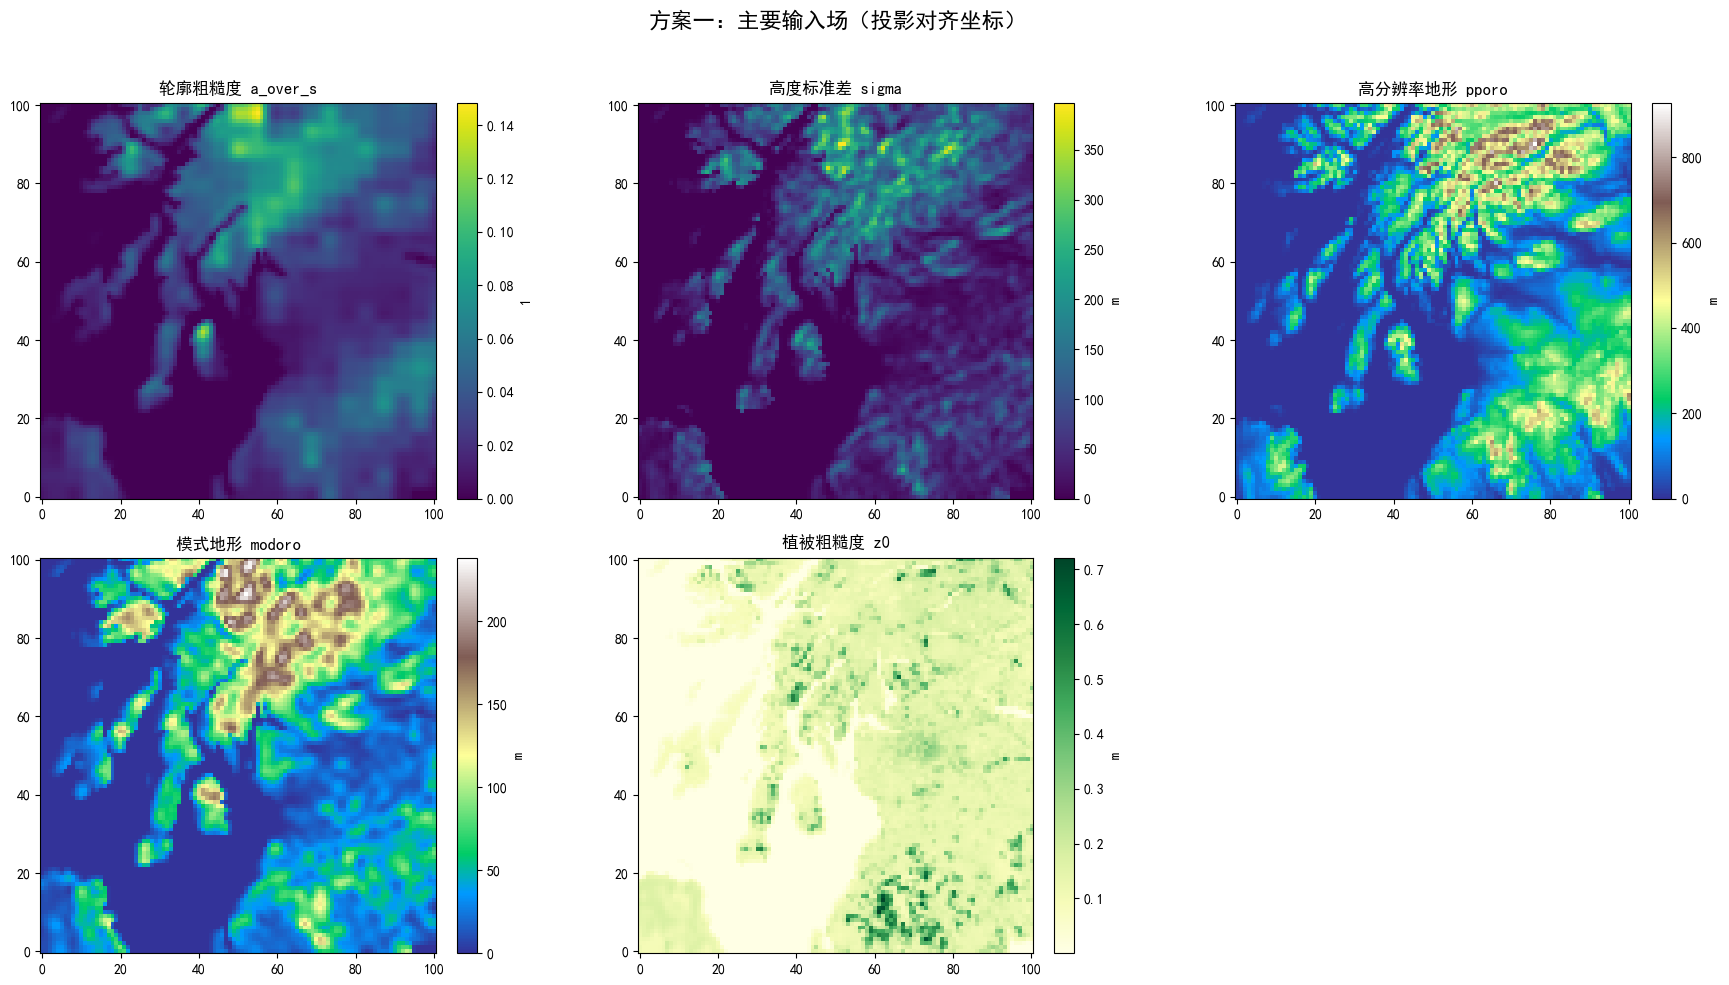

In [3]:
aux_fields = [
    ("轮廓粗糙度 a_over_s", cli_inputs["a_over_s.nc"], "viridis", "1"),
    ("高度标准差 sigma", cli_inputs["sigma.nc"], "viridis", "m"),
    ("高分辨率地形 pporo", cli_inputs["highres_orog.nc"], "terrain", "m"),
    ("模式地形 modoro", cli_inputs["standard_orog.nc"], "terrain", "m"),
    ("植被粗糙度 z0", cli_inputs["veg.nc"], "YlGn", "m"),
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()
for ax, (title, da, cmap, unit) in zip(axes, aux_fields):
    field = to_display_2d(da)
    im = ax.imshow(field, cmap=cmap, origin="lower")
    ax.set_title(title, fontsize=12)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label=unit)

for ax in axes[len(aux_fields):]:
    ax.axis("off")

fig.suptitle("方案一：主要输入场（投影对齐坐标）", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()



### 2.3 RoughnessCorrection 验证


In [4]:
# 插件方法调用
plugin_s1 = RoughnessCorrection(
    a_over_s=cli_inputs["a_over_s.nc"],
    sigma=cli_inputs["sigma.nc"],
    pporo=cli_inputs["highres_orog.nc"],
    modoro=cli_inputs["standard_orog.nc"],
    modres=MODEL_RESOLUTION,
    z0=cli_inputs["veg.nc"],
)
modified_s1 = plugin_s1.process(wind_speed_da)
print(f"方案一推断/使用 ppres (米) = {plugin_s1.ppres:.3f}")

# KGO / 原算法结果仍为根目录官方投影 nc
kgo_da = xr.open_dataset(DATA_DIR / "kgo.nc", decode_timedelta=False)["wind_speed"].load()
original_da = xr.open_dataset(
    DATA_DIR / "original_algorithm_result.nc", decode_timedelta=False
)["wind_speed_processed"].load()

print("=== 方案一：RoughnessCorrection ===")
compare_stats(modified_s1, kgo_da, "方案一 修改后-KGO")
compare_stats(modified_s1, original_da, "方案一 修改后-原算法")
compare_stats(original_da, kgo_da, "方案一 原算法-KGO")



方案一推断/使用 ppres (米) = 2000.000
=== 方案一：RoughnessCorrection ===
[方案一 修改后-KGO] mean_abs=0.00000007, max_abs=0.00001383, rmse=0.00000035
[方案一 修改后-原算法] mean_abs=0.00000007, max_abs=0.00001383, rmse=0.00000035
[方案一 原算法-KGO] mean_abs=0.00000000, max_abs=0.00000000, rmse=0.00000000


{'mean_abs': 0.0, 'max_abs': 0.0, 'rmse': 0.0}

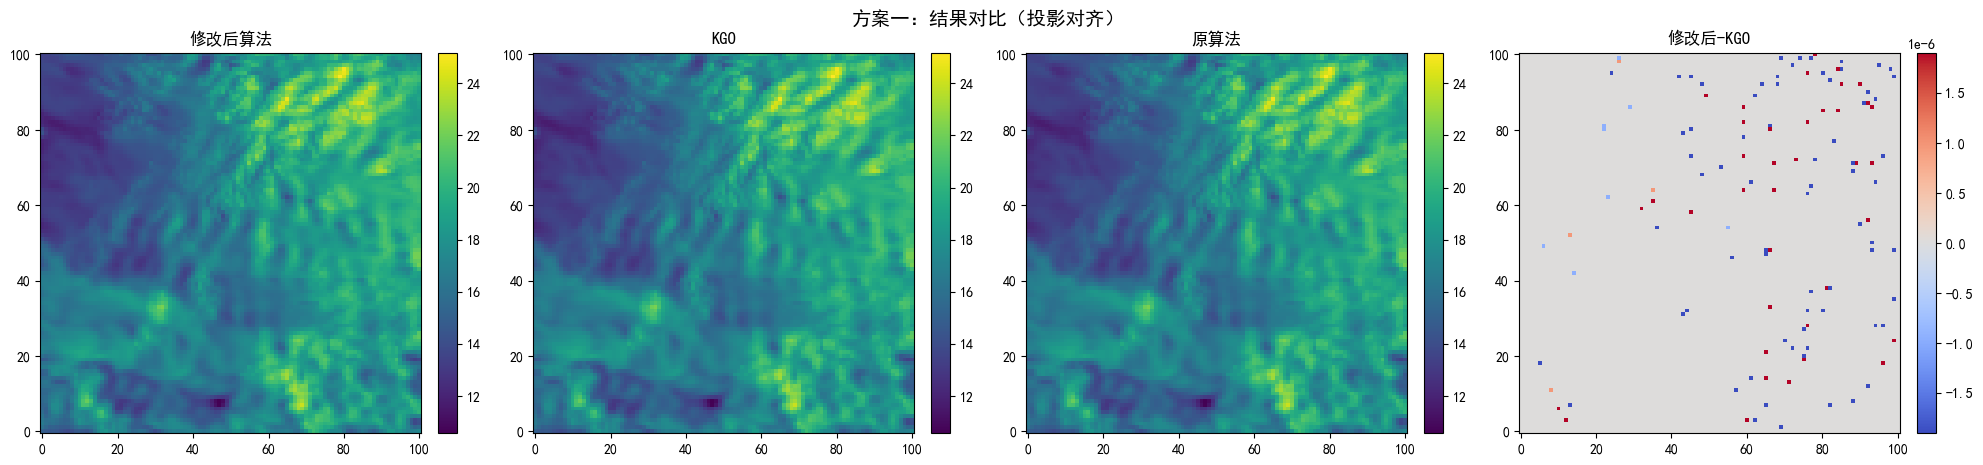

In [5]:
mod2d, _ = _to_plot_ready(modified_s1)
kgo2d, _ = _to_plot_ready(kgo_da)
orig2d, _ = _to_plot_ready(original_da)
panels = [
    ("修改后算法", mod2d),
    ("KGO", kgo2d),
    ("原算法", orig2d),
    ("修改后-KGO", mod2d - kgo2d),
]

fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))
for ax, (title, field) in zip(axes, panels):
    cmap = "coolwarm" if title.startswith("修改后-KGO") else "viridis"
    im = ax.imshow(field, origin="lower", cmap=cmap)
    ax.set_title(title)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
fig.suptitle("方案一：结果对比（投影对齐）", fontsize=14)
plt.tight_layout()
plt.show()



### 2.4 CLI 验证

CLI 从 `cli_input/` 读取输入，结果写出 `cli_output/`。

```powershell
python cli/00space_downscale/orographic_wind_downscaling/dsc_wind_downscaling_main.py
```


In [6]:
cli_result = cli_process(
    str(CLI_INPUT_DIR / "input.nc"),
    str(CLI_INPUT_DIR / "sigma.nc"),
    str(CLI_INPUT_DIR / "highres_orog.nc"),
    str(CLI_INPUT_DIR / "standard_orog.nc"),
    str(CLI_INPUT_DIR / "a_over_s.nc"),
    MODEL_RESOLUTION,
    vegetative_roughness_path=str(CLI_INPUT_DIR / "veg.nc"),
    output_path=str(CLI_OUTPUT_DIR / "cli_result.nc"),
)

original_cli_path = DATA_DIR / "original_cli_result.nc"
if original_cli_path.exists():
    original_cli_da = xr.open_dataset(original_cli_path, decode_timedelta=False)[
        "wind_speed"
    ].load()
else:
    original_cli_da = None
    print("未找到 original_cli_result.nc，跳过与原 CLI 对照。")

print("=== 方案一：CLI ===")
compare_stats(modified_s1, cli_result, "方案一 插件-修改后CLI")
if original_cli_da is not None:
    compare_stats(modified_s1, original_cli_da, "方案一 插件-原算法CLI")
    compare_stats(cli_result, original_cli_da, "方案一 修改后CLI-原算法CLI")



=== 方案一：CLI ===
[方案一 插件-修改后CLI] mean_abs=0.00000000, max_abs=0.00000000, rmse=0.00000000
[方案一 插件-原算法CLI] mean_abs=0.00000007, max_abs=0.00001383, rmse=0.00000035
[方案一 修改后CLI-原算法CLI] mean_abs=0.00000007, max_abs=0.00001383, rmse=0.00000035


## 3. 方案二：真经纬网格输入（重网格）

读取预处理写出的 `cli_input/latlon/`，运行迁移版（**不显式给 `ppres`**，由 `infer_grid_resolution_from_coords` 将度间距换算为米）。

对照：同目录下已重网格的 `kgo.nc` / `original_algorithm_result.nc`。


### 3.1 读取经纬预处理输入与对照场


In [7]:
latlon_inputs = {
    filename: xr.open_dataarray(
        CLI_INPUT_LATLON_DIR / filename, decode_timedelta=False
    ).load()
    for filename in CLI_INPUT_FILES
}
kgo_latlon = xr.open_dataarray(
    CLI_INPUT_LATLON_DIR / "kgo.nc", decode_timedelta=False
).load()
original_latlon = xr.open_dataarray(
    CLI_INPUT_LATLON_DIR / "original_algorithm_result.nc", decode_timedelta=False
).load()

wind_latlon = latlon_inputs["input.nc"]
print("方案二输入:", wind_latlon.dims, wind_latlon.shape)
print("lat 范围:", float(wind_latlon.lat.min()), float(wind_latlon.lat.max()))
print("lon 范围:", float(wind_latlon.lon.min()), float(wind_latlon.lon.max()))



方案二输入: ('member', 'level', 'time', 'dtime', 'lat', 'lon') (1, 9, 1, 1, 101, 101)
lat 范围: 54.90762454659305 56.70254560667026
lon 范围: -6.6136529084611375 -3.425214094496182


### 3.2 RoughnessCorrection 验证（ppres 由经纬推断）


In [8]:
plugin_s2 = RoughnessCorrection(
    a_over_s=latlon_inputs["a_over_s.nc"],
    sigma=latlon_inputs["sigma.nc"],
    pporo=latlon_inputs["highres_orog.nc"],
    modoro=latlon_inputs["standard_orog.nc"],
    modres=MODEL_RESOLUTION,
    z0=latlon_inputs["veg.nc"],
)
print(f"方案二推断 ppres (米) = {plugin_s2.ppres:.3f}")
modified_s2 = plugin_s2.process(wind_latlon)

print("=== 方案二：RoughnessCorrection（经纬）===")
compare_stats(modified_s2, kgo_latlon, "方案二 修改后-KGO(重网格)")
compare_stats(modified_s2, original_latlon, "方案二 修改后-原算法(重网格)")
compare_stats(original_latlon, kgo_latlon, "方案二 原算法(重网格)-KGO(重网格)")



方案二推断 ppres (米) = 1994.201
=== 方案二：RoughnessCorrection（经纬）===
[方案二 修改后-KGO(重网格)] mean_abs=0.03358617, max_abs=4.54313469, rmse=0.11233155
[方案二 修改后-原算法(重网格)] mean_abs=0.03358617, max_abs=4.54313469, rmse=0.11233155
[方案二 原算法(重网格)-KGO(重网格)] mean_abs=0.00000000, max_abs=0.00000000, rmse=0.00000000


{'mean_abs': 0.0, 'max_abs': 0.0, 'rmse': 0.0}

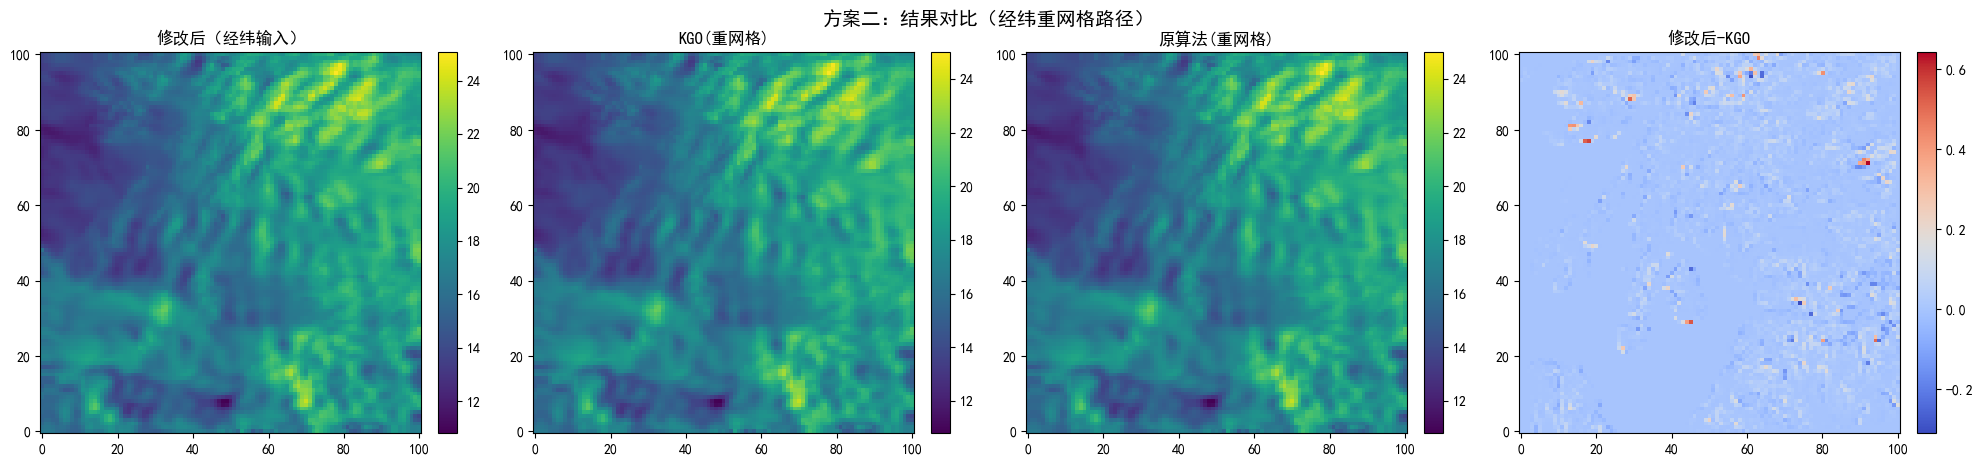

In [9]:
mod2d, _ = _to_plot_ready(modified_s2)
kgo2d, _ = _to_plot_ready(kgo_latlon)
orig2d, _ = _to_plot_ready(original_latlon)
panels = [
    ("修改后（经纬输入）", mod2d),
    ("KGO(重网格)", kgo2d),
    ("原算法(重网格)", orig2d),
    ("修改后-KGO", mod2d - kgo2d),
]

fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))
for ax, (title, field) in zip(axes, panels):
    cmap = "coolwarm" if title.startswith("修改后-KGO") else "viridis"
    im = ax.imshow(field, origin="lower", cmap=cmap)
    ax.set_title(title)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
fig.suptitle("方案二：结果对比（经纬重网格路径）", fontsize=14)
plt.tight_layout()
plt.show()



## 4. 小结

| 路径 | 输入 | `ppres` | 对照方式 | 预期差异量级 |
|------|------|---------|----------|--------------|
| 方案一 | 投影维重命名 `cli_input/` | 米制间距推断 | 直接比 KGO/原结果 | 约 `1e-5` |
| 方案二 | 真经纬 `cli_input/latlon/` | 度间距→米推断 | 原结果重网格后再比 | 通常更大（插值顺序） |

方案一用于确认算法与原版的数值一致；方案二用于确认真经纬输入与度→米 `ppres` 推断可运行，**不宜作为**与官方同精度的回归门槛。
